## Dataset - Porto Seguro Safe Driver Dataset

In [132]:
import pandas as pd
import numpy as np

df_train = pd.read_csv('../Cleaned-Dataset/train_2.csv')
df_test = pd.read_csv('../Cleaned-Dataset/test_2.csv')

In [133]:
def dataset_split(df_train, df_test):
    train_samples = int(df_train.shape[0] * 0.8)

    X_train, y_train = df_train[:train_samples].drop(columns=['target']), df_train[:train_samples]['target']
    X_valid, y_valid = df_train[train_samples:].drop(columns=['target']), df_train[train_samples:]['target']

    test = df_test
    return X_train, y_train, X_valid, y_valid, test

In [134]:
X_train, y_train, X_valid, y_valid, test = dataset_split(df_train, df_test)

## Light GBM Tree

In [103]:
import numpy as np
from sklearn.metrics import roc_auc_score

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None,
                 leaf_weight=None, leaf_count=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.leaf_weight = leaf_weight
        self.leaf_count = leaf_count


class DecisionTreeLightGBMStyle:
    def __init__(self,
                 num_leaves=127,
                 max_depth=-1,
                 min_data_in_leaf=20,
                 min_sum_hessian_in_leaf=1e-3,
                 feature_fraction=0.6,
                 bagging_fraction=0.8,
                 reg_alpha=0.1,
                 reg_lambda=5.0,
                 min_split_gain=0.0,
                 max_bin=255,
                 seed=42):
        self.num_leaves = num_leaves
        self.max_depth = max_depth
        self.min_data_in_leaf = min_data_in_leaf
        self.min_sum_hessian_in_leaf = min_sum_hessian_in_leaf
        self.feature_fraction = feature_fraction
        self.bagging_fraction = bagging_fraction
        self.reg_alpha = reg_alpha
        self.reg_lambda = reg_lambda
        self.min_split_gain = min_split_gain
        self.max_bin = max_bin
        self.seed = seed
        np.random.seed(seed)

        self.X = None
        self.bin_edges = None
        self.tree_sample_indices = None
        self.bin_ids_full = None
        self.current_num_leaves = num_leaves

    def _compute_bin_edges(self, X):
        bin_edges = []
        for f in range(X.shape[1]):
            col = X[:, f]
            unique_vals = np.unique(col)
            if len(unique_vals) <= self.max_bin:
                edges = np.sort(unique_vals)
            else:
                edges = np.percentile(col, np.linspace(0, 100, self.max_bin + 1))
                edges = np.unique(edges)
            bin_edges.append(edges.astype(np.float32))
        return bin_edges

    def _optimal_leaf_weight(self, G, H):
        G = np.float32(G)
        H = np.float32(H)
        if self.reg_alpha > 0:
            return -np.sign(G) * max(0.0, abs(G) - self.reg_alpha) / (H + self.reg_lambda)
        return -G / (H + self.reg_lambda)

    def _info_gain_vectorized(self, G, H, G_L, H_L, G_R, H_R):
        left_gain = (G_L ** 2) / (H_L + self.reg_lambda)
        right_gain = (G_R ** 2) / (H_R + self.reg_lambda)
        parent_gain = (G ** 2) / (H + self.reg_lambda)
        return 0.5 * (left_gain + right_gain - parent_gain) - self.min_split_gain

    def _best_split(self, grad, hess, leaf_indices):
        m = len(leaf_indices)
        if m < 2 * self.min_data_in_leaf:
            return None, None, None

        n_features = self.X.shape[1]
        features = np.arange(n_features)
        if self.feature_fraction < 1.0:
            n_select = max(1, int(self.feature_fraction * n_features))
            features = np.random.choice(n_features, n_select, replace=False)

        best_gain = -np.inf
        best_feature = best_threshold = None

        G = np.sum(grad[leaf_indices])
        H = np.sum(hess[leaf_indices])

        # Compute actual_rows once per leaf (small optimization)
        actual_rows = (self.tree_sample_indices[leaf_indices]
                       if self.bin_ids_full is not None else None)

        for f in features:
            bin_ids_f = (self.bin_ids_full[actual_rows, f]
                         if self.bin_ids_full is not None
                         else self.bin_ids[leaf_indices, f])

            num_bins = len(self.bin_edges[f])

            g_hist = np.bincount(bin_ids_f, weights=grad[leaf_indices], minlength=num_bins)
            h_hist = np.bincount(bin_ids_f, weights=hess[leaf_indices], minlength=num_bins)
            count_hist = np.bincount(bin_ids_f, minlength=num_bins)

            g_cum = np.cumsum(g_hist)
            h_cum = np.cumsum(h_hist)
            count_cum = np.cumsum(count_hist)

            G_L = g_cum[:-1]
            H_L = h_cum[:-1]
            left_count = count_cum[:-1]
            G_R = G - G_L
            H_R = H - H_L
            right_count = m - left_count

            valid = ((left_count >= self.min_data_in_leaf) &
                     (right_count >= self.min_data_in_leaf) &
                     (H_L >= self.min_sum_hessian_in_leaf) &
                     (H_R >= self.min_sum_hessian_in_leaf))

            if not np.any(valid):
                continue

            gains = self._info_gain_vectorized(G, H, G_L, H_L, G_R, H_R)
            gains[~valid] = -np.inf

            best_b = np.argmax(gains)
            gain = gains[best_b]

            if gain > best_gain and gain > self.min_split_gain:
                best_gain = gain
                best_feature = f
                edge_idx = best_b + 1
                best_threshold = (self.bin_edges[f][edge_idx]
                                  if edge_idx < len(self.bin_edges[f])
                                  else self.bin_edges[f][-1])

        if best_feature is None:
            return None, None, None
        return best_feature, best_threshold, best_gain

    def fit(self, X, grad, hess, bin_edges=None, tree_sample_indices=None, bin_ids_full=None):
        X = np.asarray(X, dtype=np.float32)
        self.X = X
        grad = np.asarray(grad, dtype=np.float32)
        hess = np.asarray(hess, dtype=np.float32)

        n_samples = len(grad)

        self.tree_sample_indices = (np.asarray(tree_sample_indices, dtype=np.int32)
                                    if tree_sample_indices is not None else None)

        if bin_ids_full is None:
            self.bin_ids_full = None
            self.bin_edges = bin_edges if bin_edges is not None else self._compute_bin_edges(X)
            self.bin_ids = np.empty((X.shape[0], X.shape[1]), dtype=np.uint8)
            for f in range(X.shape[1]):
                ids = np.searchsorted(self.bin_edges[f], X[:, f])
                self.bin_ids[:, f] = np.minimum(ids, len(self.bin_edges[f]) - 1).astype(np.uint8)
        else:
            self.bin_ids_full = bin_ids_full
            self.bin_edges = bin_edges
            self.bin_ids = None

        indices = np.arange(n_samples, dtype=np.int32)
        if self.bagging_fraction < 1.0:
            sample_size = max(1, int(self.bagging_fraction * n_samples))
            indices = np.random.choice(indices, sample_size, replace=False)

        G = np.sum(grad[indices])
        H = np.sum(hess[indices])
        w = self._optimal_leaf_weight(G, H)
        self.root = Node(leaf_weight=w, leaf_count=len(indices))

        active_leaves = [(self.root, indices.copy(), 0)]
        current_num_leaves = 1

        while current_num_leaves < self.num_leaves:
            best_gain_overall = -np.inf
            best_leaf_idx = -1
            best_feature = best_threshold = None
            best_left_indices = best_right_indices = None

            for i, (leaf_node, leaf_indices, depth) in enumerate(active_leaves):
                if self.max_depth != -1 and depth >= self.max_depth:
                    continue
                if len(leaf_indices) < 2 * self.min_data_in_leaf:
                    continue

                feat, thresh, gain = self._best_split(grad, hess, leaf_indices)
                if feat is None:
                    continue

                if gain > best_gain_overall:
                    best_gain_overall = gain
                    best_leaf_idx = i
                    best_feature = feat
                    best_threshold = thresh

                    if self.bin_ids_full is not None:
                        actual_rows = self.tree_sample_indices[leaf_indices]
                        mask = self.X[actual_rows, feat] <= thresh
                    else:
                        mask = self.X[leaf_indices, feat] <= thresh

                    best_left_indices = leaf_indices[mask]
                    best_right_indices = leaf_indices[~mask]

            if best_leaf_idx == -1 or best_gain_overall <= 0:
                break

            best_leaf_node, _, depth = active_leaves[best_leaf_idx]
            best_leaf_node.feature = best_feature
            best_leaf_node.threshold = best_threshold
            best_leaf_node.leaf_weight = None

            G_L = np.sum(grad[best_left_indices])
            H_L = np.sum(hess[best_left_indices])
            w_L = self._optimal_leaf_weight(G_L, H_L)
            left_node = Node(leaf_weight=w_L, leaf_count=len(best_left_indices))

            G_R = np.sum(grad[best_right_indices])
            H_R = np.sum(hess[best_right_indices])
            w_R = self._optimal_leaf_weight(G_R, H_R)
            right_node = Node(leaf_weight=w_R, leaf_count=len(best_right_indices))

            best_leaf_node.left = left_node
            best_leaf_node.right = right_node

            active_leaves.pop(best_leaf_idx)
            active_leaves.append((left_node, best_left_indices, depth + 1))
            active_leaves.append((right_node, best_right_indices, depth + 1))
            current_num_leaves += 1

        self.current_num_leaves = current_num_leaves
        # MEMORY CLEANUP
        self.tree_sample_indices = None
        self.bin_ids = None
        self.bin_ids_full = None
        self.X = None
        return self

    def predict(self, X):
        if not isinstance(X, np.ndarray) or X.dtype != np.float32:
            X = np.asarray(X, dtype=np.float32)
        n = X.shape[0]
        out = np.zeros(n, dtype=np.float32)
        indices = np.arange(n)
        stack = [(self.root, indices)]

        while stack:
            node, idx = stack.pop()
            if node.leaf_weight is not None:
                out[idx] = node.leaf_weight
            else:
                left_mask = X[idx, node.feature] <= node.threshold
                right_mask = ~left_mask
                if np.any(left_mask):
                    stack.append((node.left, idx[left_mask]))
                if np.any(right_mask):
                    stack.append((node.right, idx[right_mask]))
        return out

## LightGBM

In [104]:
class LightGBM:
    def __init__(self,
                 num_iterations=3000,
                 learning_rate=0.03,
                 num_leaves=127,
                 max_depth=-1,
                 min_data_in_leaf=20,
                 min_sum_hessian_in_leaf=1e-3,
                 feature_fraction=0.6,
                 bagging_fraction=0.8,
                 bagging_freq=5,               # NEW
                 reg_alpha=0.1,
                 reg_lambda=5.0,
                 min_split_gain=0.0,
                 max_bin=255,
                 boosting_type='goss',
                 top_rate=0.2,
                 other_rate=0.1,
                 scale_pos_weight=26.5,        # CRITICAL default
                 early_stopping_rounds=150,
                 verbose_eval=50,
                 seed=42):
        self.num_iterations = num_iterations
        self.learning_rate = learning_rate
        self.num_leaves = num_leaves
        self.max_depth = max_depth
        self.min_data_in_leaf = min_data_in_leaf
        self.min_sum_hessian_in_leaf = min_sum_hessian_in_leaf
        self.feature_fraction = feature_fraction
        self.bagging_fraction = bagging_fraction
        self.bagging_freq = bagging_freq
        self.reg_alpha = reg_alpha
        self.reg_lambda = reg_lambda
        self.min_split_gain = min_split_gain
        self.max_bin = max_bin
        self.boosting_type = boosting_type
        self.top_rate = top_rate
        self.other_rate = other_rate
        self.scale_pos_weight = scale_pos_weight
        self.early_stopping_rounds = early_stopping_rounds
        self.verbose_eval = verbose_eval
        self.seed = seed

        self.trees = []
        self.base_score = None
        self.best_iteration_ = None
        self.best_val_auc = None
        self.test_pred = None
        self.current_num_leaves = []
        np.random.seed(seed)

    def _apply_goss(self, grad, hess):
        n = len(grad)
        abs_grad = np.abs(grad)
        sorted_idx = np.argsort(abs_grad)[::-1]
        n_top = max(1, int(self.top_rate * n))
        n_other = max(1, int(self.other_rate * n))
        top_indices = sorted_idx[:n_top]
        other_candidates = sorted_idx[n_top:]

        other_sample = (np.random.choice(other_candidates, min(n_other, len(other_candidates)), replace=False)
                        if n_other > 0 and len(other_candidates) > 0 else np.array([], dtype=np.int32))

        sampled_indices = np.concatenate([top_indices, other_sample])
        sampled_grad = grad[sampled_indices].copy().astype(np.float32)
        sampled_hess = hess[sampled_indices].copy().astype(np.float32)

        adjust_factor = (1.0 - self.top_rate) / self.other_rate if self.other_rate > 0 else 1.0
        small_mask = ~np.isin(sampled_indices, top_indices)
        sampled_grad[small_mask] *= adjust_factor
        sampled_hess[small_mask] *= adjust_factor

        return sampled_indices, sampled_grad, sampled_hess

    def fit(self, X, y, X_valid=None, y_valid=None, test=None):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32).ravel()

        n_pos = np.sum(y == 1)
        n_neg = len(y) - n_pos
        p_eff = (self.scale_pos_weight * n_pos) / (self.scale_pos_weight * n_pos + n_neg) if n_pos > 0 and n_neg > 0 else 0.5
        self.base_score = np.float32(np.log(p_eff / (1 - p_eff)) if 0 < p_eff < 1 else 0.0)

        print(f"LightGBM from Scratch (optimized) -> base_score = {self.base_score:.6f} "
              f"(initial prob = {1/(1+np.exp(-self.base_score)):.6f}, scale_pos_weight={self.scale_pos_weight})")

        self.best_iteration_ = self.num_iterations
        pred = np.full(len(y), self.base_score, dtype=np.float32)

        do_eval = X_valid is not None and y_valid is not None
        if do_eval:
            X_valid = np.asarray(X_valid, dtype=np.float32)
            y_valid = np.asarray(y_valid, dtype=np.float32).ravel()
            val_pred = np.full(len(y_valid), self.base_score, dtype=np.float32)

        if test is not None:
            test = np.asarray(test, dtype=np.float32)
            test_pred_score = np.full(len(test), self.base_score, dtype=np.float32)

        # Global pre-computation (once)
        _dummy = DecisionTreeLightGBMStyle(max_bin=self.max_bin)
        self.shared_bin_edges = _dummy._compute_bin_edges(X)
        n_train, n_feat = X.shape
        self.bin_ids_full = np.empty((n_train, n_feat), dtype=np.uint8)
        for f in range(n_feat):
            ids = np.searchsorted(self.shared_bin_edges[f], X[:, f])
            self.bin_ids_full[:, f] = np.minimum(ids, len(self.shared_bin_edges[f]) - 1).astype(np.uint8)

        self.best_val_auc = -np.inf
        no_improve = 0
        bagging_counter = 0

        for t in range(self.num_iterations):
            p = 1 / (1 + np.exp(-np.clip(pred, -35, 35)))
            grad = (p - y).astype(np.float32)
            hess = (p * (1 - p)).astype(np.float32)
            grad[y == 1] *= self.scale_pos_weight
            hess[y == 1] *= self.scale_pos_weight

            if self.boosting_type == 'goss':
                sampled_idx, grad_sample, hess_sample = self._apply_goss(grad, hess)
                tree_sample_indices = sampled_idx
            else:
                sampled_idx = np.arange(len(y), dtype=np.int32)
                grad_sample = grad
                hess_sample = hess
                tree_sample_indices = sampled_idx

            # Refresh bagging every bagging_freq trees
            bagging_counter += 1
            if bagging_counter % self.bagging_freq == 0:
                # force new bagging on next tree (already handled in tree.fit)
                pass

            tree = DecisionTreeLightGBMStyle(
                num_leaves=self.num_leaves,
                max_depth=self.max_depth,
                min_data_in_leaf=self.min_data_in_leaf,
                min_sum_hessian_in_leaf=self.min_sum_hessian_in_leaf,
                feature_fraction=self.feature_fraction,
                bagging_fraction=self.bagging_fraction,
                reg_alpha=self.reg_alpha,
                reg_lambda=self.reg_lambda,
                min_split_gain=self.min_split_gain,
                max_bin=self.max_bin,
                seed=self.seed + t
            )

            tree.fit(X, grad_sample, hess_sample,
                     bin_edges=self.shared_bin_edges,
                     tree_sample_indices=tree_sample_indices,
                     bin_ids_full=self.bin_ids_full)

            self.trees.append(tree)
            self.current_num_leaves.append(tree.current_num_leaves)
            
            tree_output = tree.predict(X)
            pred += self.learning_rate * tree_output

            if do_eval:
                val_pred += self.learning_rate * tree.predict(X_valid)
            if test is not None:
                test_pred_score += self.learning_rate * tree.predict(test)

            if (t + 1) % self.verbose_eval == 0:
                train_p = 1 / (1 + np.exp(-pred))
                train_auc = roc_auc_score(y, train_p)
                msg = f"Tree {t+1}/{self.num_iterations} | Train AUC: {train_auc:.5f} (GOSS)"

                if do_eval:
                    val_p = 1 / (1 + np.exp(-val_pred))
                    val_auc = roc_auc_score(y_valid, val_p)
                    msg += f" | Val AUC: {val_auc:.5f}"

                    if val_auc > self.best_val_auc + 1e-5:
                        self.best_val_auc = val_auc
                        self.best_iteration_ = t + 1
                        no_improve = 0
                    else:
                        no_improve += self.verbose_eval
                        if self.early_stopping_rounds is not None and no_improve >= self.early_stopping_rounds:
                            print(msg)
                            print(f"Early stopping at round {t+1}. Best val AUC: {self.best_val_auc:.5f}")
                            if test is not None:
                                self.test_pred = 1 / (1 + np.exp(-test_pred_score))
                            self.trees = self.trees[:self.best_iteration_]  # trim
                            return self
                print(msg)

        if test is not None:
            self.test_pred = 1 / (1 + np.exp(-test_pred_score))
        self.trees = self.trees[:self.best_iteration_]  # trim
        return self

    def predict_raw(self, X):
        if not isinstance(X, np.ndarray):
            X = np.array(X, dtype=np.float32)
        raw = np.full(X.shape[0], self.base_score, dtype=np.float32)
        for tree in self.trees[:self.best_iteration_]:
            raw += self.learning_rate * tree.predict(X)
        return raw

    def predict_proba(self, X):
        raw = self.predict_raw(X)
        return 1 / (1 + np.exp(-raw))

    def predict(self, X, threshold=0.2):
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

## Hyper Parameter tuning

### Dataset

In [32]:
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]

len(neg_idx)/len(pos_idx)

26.459143071333834

In [33]:
subset_size = 55000

rng = np.random.RandomState(42)

sample_pos = rng.choice(pos_idx, size = 2000, replace=False)
sample_neg = rng.choice(neg_idx, size = 53000, replace=False)
sample_idx = np.concatenate([sample_pos, sample_neg])

X_train_sub, y_train_sub = X_train.iloc[sample_idx], y_train.iloc[sample_idx]

default_parameters = {
    'num_iterations': 300, 
    'learning_rate': 0.05, 

    'num_leaves': 31,
    'max_depth': 3, 
    'min_data_in_leaf': 20,
    'min_sum_hessian_in_leaf': 1e-3,

    'feature_fraction': 0.8, 
    'bagging_fraction': 0.8, 

    'reg_alpha': 0.0, 
    'reg_lambda': 1.0,

    'min_split_gain': 0.0, 
    'max_bin': 255,
    'boosting_type': 'goss',
    'top_rate': 0.2,
    'other_rate': 0.1,
    'scale_pos_weight': 1.0, 
    'early_stopping_rounds': None,
    'verbose_eval': 20,
    'seed': 42
}


### Tune and Plot

In [22]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

def tune(param_name, param_values):
    """Train and plot the graph"""
    auc_scores = []
    xticks = []
    for val in param_values:
        params = default_parameters.copy()
        params[param_name] = val
        print(f"Started on {param_name}: {val}")
        model_lgb = LightGBM(**params)
        model_lgb.fit(X_train_sub, y_train_sub, X_valid, y_valid)
        auc = model_lgb.best_val_auc
        # auc = roc_auc_score(y_valid, preds)

        val_str = "None" if val is None else str(val)
        print(f" Trained model on {param_name}: {val_str:10} -> AUC: {auc:.5f}")
        auc_scores.append(auc)
        xticks.append(val_str)
    return auc_scores, xticks

def plot(param_name, param_values, xlabel, auc_scores, xticks):
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(param_values)), auc_scores, marker='o', linewidth=2, markersize=8)
    plt.xticks(range(len(param_values)), xticks, rotation=45)
    plt.title(f'AUC Score vs {param_name}', fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Validation AUC Score', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return auc_scores

-    'n_estimators': 300, 
-    'learning_rate': 0.05, 

    -    'num_leaves': 31,
    -    'max_depth': 3, 
    -    'min_data_in_leaf': 20,
    -    'min_sum_hessian_in_leaf': 1e-3,

    -    'feature_fraction': 0.8, 
    -    'bagging_fraction': 0.8, 

    -    'reg_alpha': 0.0, 
    -    'reg_lambda': 1.0,

    -    'min_split_gain': 0.0, 
    -    'max_bin': 255,
    -    'boosting_type': 'goss',
    -    'top_rate': 0.2,
    -    'other_rate': 0.1,
    -    'scale_pos_weight': 1.0, 

-    'early_stopping_rounds': None,
-    'verbose_eval': 20,


Started on num_leaves: 15
LightGBM from Scratch (vectorized) -> base_score = -3.277145 (initial prob = 0.036364, scale_pos_weight=1.0)
Tree 20/300 | Train AUC: 0.58860 (GOSS) | Val AUC: 0.59314
Tree 40/300 | Train AUC: 0.59782 (GOSS) | Val AUC: 0.60365
Tree 60/300 | Train AUC: 0.59918 (GOSS) | Val AUC: 0.60460
Tree 80/300 | Train AUC: 0.60343 (GOSS) | Val AUC: 0.60852
Tree 100/300 | Train AUC: 0.60344 (GOSS) | Val AUC: 0.60849
Tree 120/300 | Train AUC: 0.60251 (GOSS) | Val AUC: 0.60746
Tree 140/300 | Train AUC: 0.60391 (GOSS) | Val AUC: 0.60814
Tree 160/300 | Train AUC: 0.60415 (GOSS) | Val AUC: 0.60799
Tree 180/300 | Train AUC: 0.60403 (GOSS) | Val AUC: 0.60829
Tree 200/300 | Train AUC: 0.60523 (GOSS) | Val AUC: 0.60914
Tree 220/300 | Train AUC: 0.60533 (GOSS) | Val AUC: 0.60940
Tree 240/300 | Train AUC: 0.60536 (GOSS) | Val AUC: 0.60958
Tree 260/300 | Train AUC: 0.60536 (GOSS) | Val AUC: 0.60935
Tree 280/300 | Train AUC: 0.60595 (GOSS) | Val AUC: 0.60985
Tree 300/300 | Train AUC: 0.6

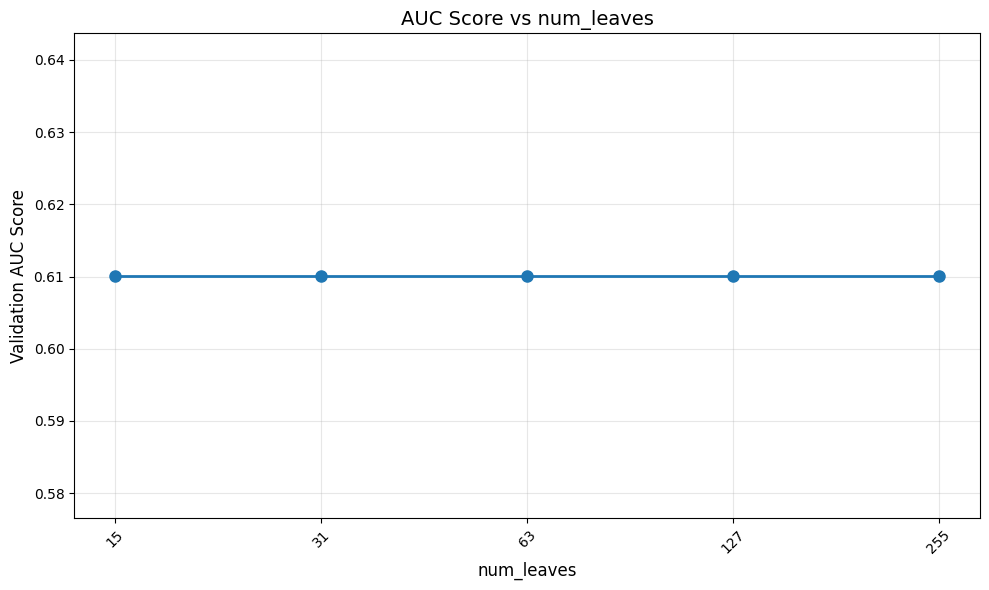

[0.6101350343479262,
 0.6101350343479262,
 0.6101350343479262,
 0.6101350343479262,
 0.6101350343479262]

In [34]:
# num_leaves
param_values = [15, 31, 63, 127, 255]
auc_scores, xticks = tune('num_leaves', param_values)
plot('num_leaves', param_values, 'num_leaves', auc_scores, xticks)

Started on min_data_in_leaf: 2
LightGBM from Scratch (vectorized) -> base_score = -3.277145 (initial prob = 0.036364, scale_pos_weight=1.0)
Tree 20/300 | Train AUC: 0.58860 (GOSS) | Val AUC: 0.59314
Tree 40/300 | Train AUC: 0.59821 (GOSS) | Val AUC: 0.60338
Tree 60/300 | Train AUC: 0.60293 (GOSS) | Val AUC: 0.60641
Tree 80/300 | Train AUC: 0.60362 (GOSS) | Val AUC: 0.60772
Tree 100/300 | Train AUC: 0.60365 (GOSS) | Val AUC: 0.60771
Tree 120/300 | Train AUC: 0.60413 (GOSS) | Val AUC: 0.60788
Tree 140/300 | Train AUC: 0.60399 (GOSS) | Val AUC: 0.60802
Tree 160/300 | Train AUC: 0.60385 (GOSS) | Val AUC: 0.60762
Tree 180/300 | Train AUC: 0.60428 (GOSS) | Val AUC: 0.60824
Tree 200/300 | Train AUC: 0.60510 (GOSS) | Val AUC: 0.60938
Tree 220/300 | Train AUC: 0.60577 (GOSS) | Val AUC: 0.60985
Tree 240/300 | Train AUC: 0.60580 (GOSS) | Val AUC: 0.60999
Tree 260/300 | Train AUC: 0.60646 (GOSS) | Val AUC: 0.61028
Tree 280/300 | Train AUC: 0.60648 (GOSS) | Val AUC: 0.61057
Tree 300/300 | Train AUC

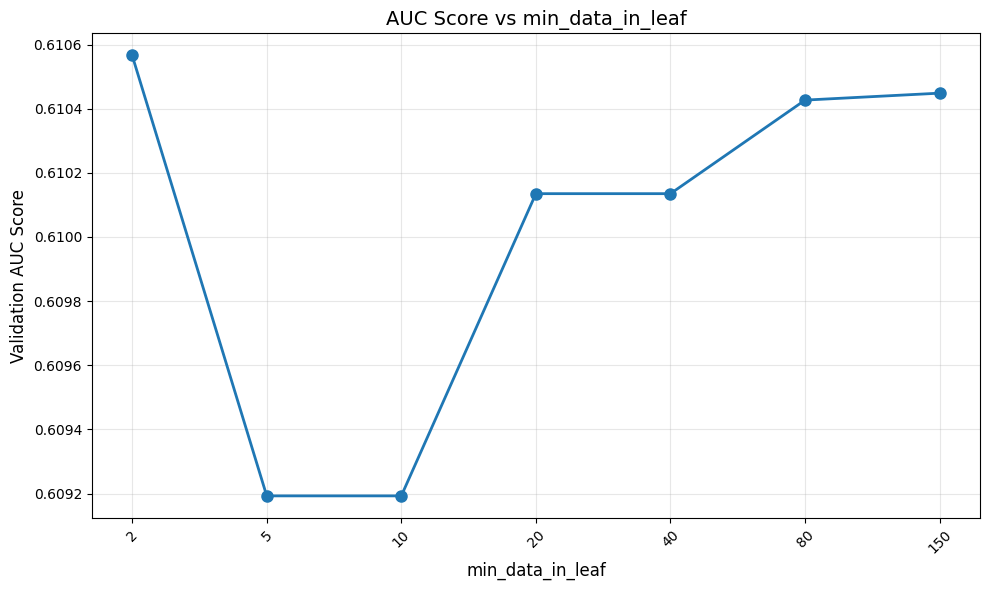

[0.6105663070780979,
 0.6091926724557616,
 0.6091926724557616,
 0.6101350343479262,
 0.6101350343479262,
 0.6104267915687264,
 0.6104484622667758]

In [35]:
# min_data_in_leaf
param_values = [2, 5, 10, 20, 40, 80, 150]
auc_scores, xticks = tune('min_data_in_leaf', param_values)
plot('min_data_in_leaf', param_values, 'min_data_in_leaf', auc_scores, xticks)

Started on min_sum_hessian_in_leaf: 1e-05
LightGBM from Scratch (vectorized) -> base_score = -3.277145 (initial prob = 0.036364, scale_pos_weight=1.0)
Tree 20/300 | Train AUC: 0.58860 (GOSS) | Val AUC: 0.59314
Tree 40/300 | Train AUC: 0.59782 (GOSS) | Val AUC: 0.60365
Tree 60/300 | Train AUC: 0.59918 (GOSS) | Val AUC: 0.60460
Tree 80/300 | Train AUC: 0.60343 (GOSS) | Val AUC: 0.60852
Tree 100/300 | Train AUC: 0.60344 (GOSS) | Val AUC: 0.60849
Tree 120/300 | Train AUC: 0.60251 (GOSS) | Val AUC: 0.60746
Tree 140/300 | Train AUC: 0.60391 (GOSS) | Val AUC: 0.60814
Tree 160/300 | Train AUC: 0.60415 (GOSS) | Val AUC: 0.60799
Tree 180/300 | Train AUC: 0.60403 (GOSS) | Val AUC: 0.60829
Tree 200/300 | Train AUC: 0.60523 (GOSS) | Val AUC: 0.60914
Tree 220/300 | Train AUC: 0.60533 (GOSS) | Val AUC: 0.60940
Tree 240/300 | Train AUC: 0.60536 (GOSS) | Val AUC: 0.60958
Tree 260/300 | Train AUC: 0.60536 (GOSS) | Val AUC: 0.60935
Tree 280/300 | Train AUC: 0.60595 (GOSS) | Val AUC: 0.60985
Tree 300/300 

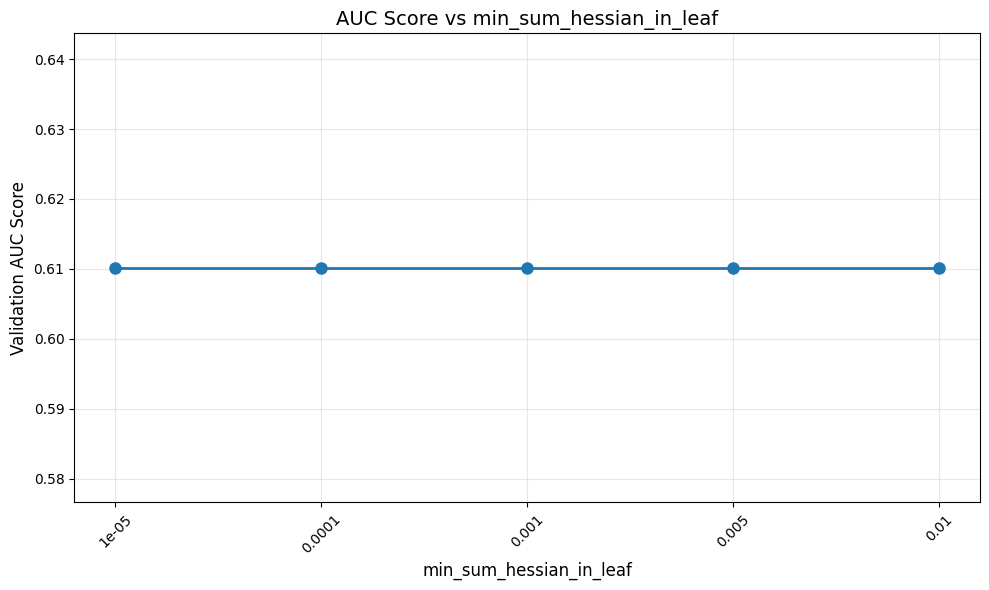

[0.6101350343479262,
 0.6101350343479262,
 0.6101350343479262,
 0.6101350343479262,
 0.6101350343479262]

In [36]:
# min_sum_hessian_in_leaf
param_values = [1e-5, 1e-4, 1e-3, 5e-3, 1e-2]
auc_scores, xticks = tune('min_sum_hessian_in_leaf', param_values)
plot('min_sum_hessian_in_leaf', param_values, 'min_sum_hessian_in_leaf', auc_scores, xticks)

Started on feature_fraction: 0.1
LightGBM from Scratch (vectorized) -> base_score = -3.277145 (initial prob = 0.036364, scale_pos_weight=1.0)
Tree 20/300 | Train AUC: 0.60716 (GOSS) | Val AUC: 0.60534
Tree 40/300 | Train AUC: 0.61306 (GOSS) | Val AUC: 0.61150
Tree 60/300 | Train AUC: 0.61543 (GOSS) | Val AUC: 0.61335
Tree 80/300 | Train AUC: 0.61928 (GOSS) | Val AUC: 0.61346
Tree 100/300 | Train AUC: 0.62179 (GOSS) | Val AUC: 0.61485
Tree 120/300 | Train AUC: 0.62281 (GOSS) | Val AUC: 0.61518
Tree 140/300 | Train AUC: 0.62421 (GOSS) | Val AUC: 0.61606
Tree 160/300 | Train AUC: 0.62626 (GOSS) | Val AUC: 0.61644
Tree 180/300 | Train AUC: 0.62815 (GOSS) | Val AUC: 0.61653
Tree 200/300 | Train AUC: 0.62935 (GOSS) | Val AUC: 0.61574
Tree 220/300 | Train AUC: 0.63046 (GOSS) | Val AUC: 0.61564
Tree 240/300 | Train AUC: 0.63169 (GOSS) | Val AUC: 0.61607
Tree 260/300 | Train AUC: 0.63316 (GOSS) | Val AUC: 0.61646
Tree 280/300 | Train AUC: 0.63456 (GOSS) | Val AUC: 0.61594
Tree 300/300 | Train A

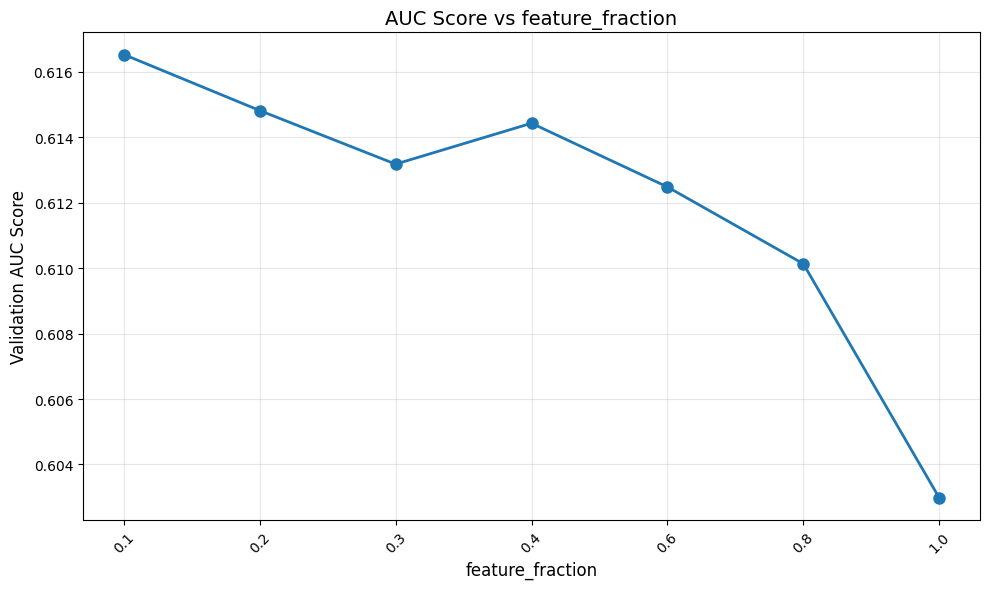

[0.6165323159502447,
 0.6148197208840531,
 0.613181295729875,
 0.6144311676115624,
 0.612483813326576,
 0.6101350343479262,
 0.6029804721151557]

In [37]:
# feature_fraction
param_values = [0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0]
auc_scores, xticks = tune('feature_fraction', param_values)
plot('feature_fraction', param_values, 'feature_fraction', auc_scores, xticks)

Started on reg_alpha: 0.0
LightGBM from Scratch (vectorized) -> base_score = -3.277145 (initial prob = 0.036364, scale_pos_weight=1.0)
Tree 20/300 | Train AUC: 0.58860 (GOSS) | Val AUC: 0.59314
Tree 40/300 | Train AUC: 0.59782 (GOSS) | Val AUC: 0.60365
Tree 60/300 | Train AUC: 0.59918 (GOSS) | Val AUC: 0.60460
Tree 80/300 | Train AUC: 0.60343 (GOSS) | Val AUC: 0.60852
Tree 100/300 | Train AUC: 0.60344 (GOSS) | Val AUC: 0.60849
Tree 120/300 | Train AUC: 0.60251 (GOSS) | Val AUC: 0.60746
Tree 140/300 | Train AUC: 0.60391 (GOSS) | Val AUC: 0.60814
Tree 160/300 | Train AUC: 0.60415 (GOSS) | Val AUC: 0.60799
Tree 180/300 | Train AUC: 0.60403 (GOSS) | Val AUC: 0.60829
Tree 200/300 | Train AUC: 0.60523 (GOSS) | Val AUC: 0.60914
Tree 220/300 | Train AUC: 0.60533 (GOSS) | Val AUC: 0.60940
Tree 240/300 | Train AUC: 0.60536 (GOSS) | Val AUC: 0.60958
Tree 260/300 | Train AUC: 0.60536 (GOSS) | Val AUC: 0.60935
Tree 280/300 | Train AUC: 0.60595 (GOSS) | Val AUC: 0.60985
Tree 300/300 | Train AUC: 0.6

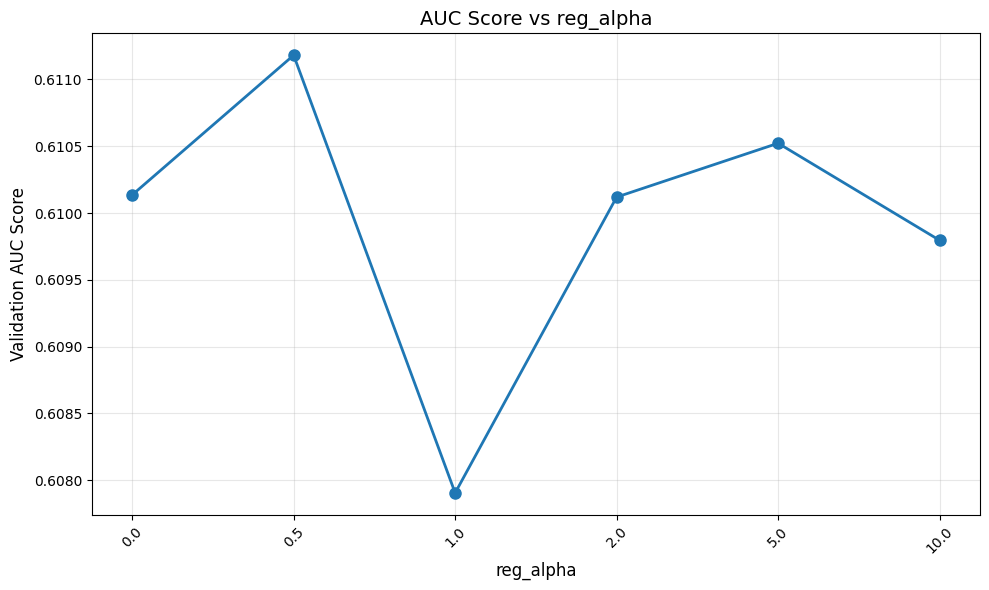

[0.6101350343479262,
 0.6111807221444149,
 0.6079052529199208,
 0.6101191183328877,
 0.6105220482977946,
 0.6097954840140095]

In [38]:
# reg_alpha
param_values = [0.0, 0.5, 1.0, 2.0, 5.0, 10.0]
auc_scores, xticks = tune('reg_alpha', param_values)
plot('reg_alpha', param_values, 'reg_alpha', auc_scores, xticks)

Started on reg_lambda: 1.0
LightGBM from Scratch (vectorized) -> base_score = -3.277145 (initial prob = 0.036364, scale_pos_weight=1.0)
Tree 20/300 | Train AUC: 0.58860 (GOSS) | Val AUC: 0.59314
Tree 40/300 | Train AUC: 0.59782 (GOSS) | Val AUC: 0.60365
Tree 60/300 | Train AUC: 0.59918 (GOSS) | Val AUC: 0.60460
Tree 80/300 | Train AUC: 0.60343 (GOSS) | Val AUC: 0.60852
Tree 100/300 | Train AUC: 0.60344 (GOSS) | Val AUC: 0.60849
Tree 120/300 | Train AUC: 0.60251 (GOSS) | Val AUC: 0.60746
Tree 140/300 | Train AUC: 0.60391 (GOSS) | Val AUC: 0.60814
Tree 160/300 | Train AUC: 0.60415 (GOSS) | Val AUC: 0.60799
Tree 180/300 | Train AUC: 0.60403 (GOSS) | Val AUC: 0.60829
Tree 200/300 | Train AUC: 0.60523 (GOSS) | Val AUC: 0.60914
Tree 220/300 | Train AUC: 0.60533 (GOSS) | Val AUC: 0.60940
Tree 240/300 | Train AUC: 0.60536 (GOSS) | Val AUC: 0.60958
Tree 260/300 | Train AUC: 0.60536 (GOSS) | Val AUC: 0.60935
Tree 280/300 | Train AUC: 0.60595 (GOSS) | Val AUC: 0.60985
Tree 300/300 | Train AUC: 0.

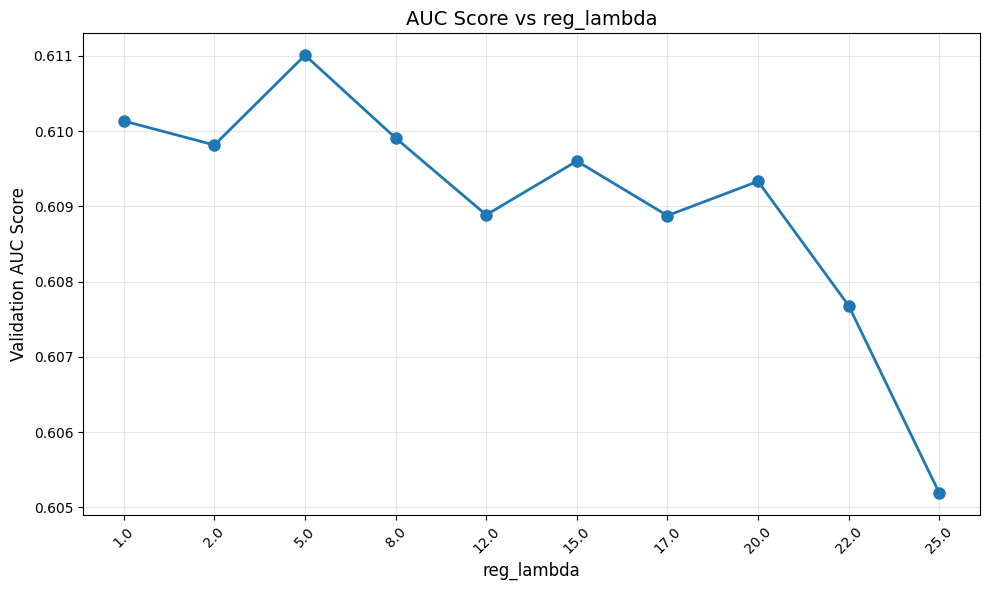

[0.6101350343479262,
 0.6098149443769726,
 0.6110084401950728,
 0.6099082010882941,
 0.6088865515621901,
 0.6096016295147096,
 0.6088770101655585,
 0.609332788871817,
 0.607681661551849,
 0.6051920620948125]

In [39]:
# reg_lambda
param_values = [1.0, 2.0, 5.0, 8.0, 12.0, 15.0, 17.0, 20.0, 22.0, 25.0]
auc_scores, xticks = tune('reg_lambda', param_values)
plot('reg_lambda', param_values, 'reg_lambda', auc_scores, xticks)

Started on min_split_gain: 0.0
LightGBM from Scratch (vectorized) -> base_score = -3.277145 (initial prob = 0.036364, scale_pos_weight=1.0)
Tree 20/300 | Train AUC: 0.58860 (GOSS) | Val AUC: 0.59314
Tree 40/300 | Train AUC: 0.59782 (GOSS) | Val AUC: 0.60365
Tree 60/300 | Train AUC: 0.59918 (GOSS) | Val AUC: 0.60460
Tree 80/300 | Train AUC: 0.60343 (GOSS) | Val AUC: 0.60852
Tree 100/300 | Train AUC: 0.60344 (GOSS) | Val AUC: 0.60849
Tree 120/300 | Train AUC: 0.60251 (GOSS) | Val AUC: 0.60746
Tree 140/300 | Train AUC: 0.60391 (GOSS) | Val AUC: 0.60814
Tree 160/300 | Train AUC: 0.60415 (GOSS) | Val AUC: 0.60799
Tree 180/300 | Train AUC: 0.60403 (GOSS) | Val AUC: 0.60829
Tree 200/300 | Train AUC: 0.60523 (GOSS) | Val AUC: 0.60914
Tree 220/300 | Train AUC: 0.60533 (GOSS) | Val AUC: 0.60940
Tree 240/300 | Train AUC: 0.60536 (GOSS) | Val AUC: 0.60958
Tree 260/300 | Train AUC: 0.60536 (GOSS) | Val AUC: 0.60935
Tree 280/300 | Train AUC: 0.60595 (GOSS) | Val AUC: 0.60985
Tree 300/300 | Train AUC

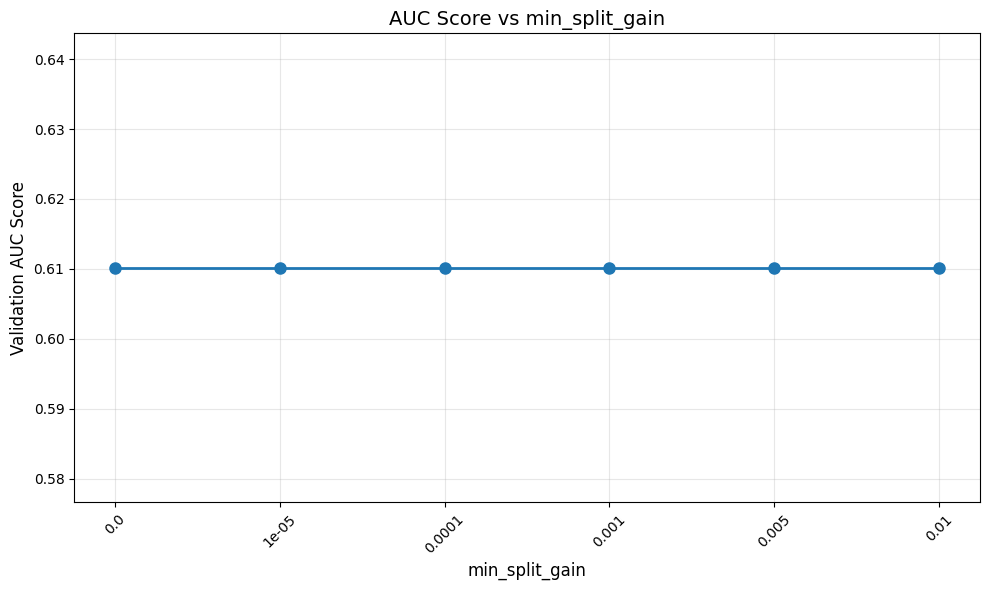

[0.6101350343479262,
 0.6101350343479262,
 0.6101350343479262,
 0.6101350343479262,
 0.6101350343479262,
 0.6101350343479262]

In [40]:
# min_split_gain
param_values = [0.0, 1e-5, 1e-4, 1e-3, 5e-3, 1e-2]
auc_scores, xticks = tune('min_split_gain', param_values)
plot('min_split_gain', param_values, 'min_split_gain', auc_scores, xticks)

Started on max_bin: 31
LightGBM from Scratch (vectorized) -> base_score = -3.277145 (initial prob = 0.036364, scale_pos_weight=1.0)
Tree 20/300 | Train AUC: 0.58971 (GOSS) | Val AUC: 0.59739
Tree 40/300 | Train AUC: 0.59602 (GOSS) | Val AUC: 0.60214
Tree 60/300 | Train AUC: 0.59840 (GOSS) | Val AUC: 0.60411
Tree 80/300 | Train AUC: 0.59956 (GOSS) | Val AUC: 0.60429
Tree 100/300 | Train AUC: 0.59906 (GOSS) | Val AUC: 0.60413
Tree 120/300 | Train AUC: 0.59997 (GOSS) | Val AUC: 0.60461
Tree 140/300 | Train AUC: 0.60154 (GOSS) | Val AUC: 0.60567
Tree 160/300 | Train AUC: 0.60177 (GOSS) | Val AUC: 0.60575
Tree 180/300 | Train AUC: 0.60177 (GOSS) | Val AUC: 0.60578
Tree 200/300 | Train AUC: 0.60187 (GOSS) | Val AUC: 0.60571
Tree 220/300 | Train AUC: 0.60256 (GOSS) | Val AUC: 0.60611
Tree 240/300 | Train AUC: 0.60316 (GOSS) | Val AUC: 0.60705
Tree 260/300 | Train AUC: 0.60388 (GOSS) | Val AUC: 0.60777
Tree 280/300 | Train AUC: 0.60458 (GOSS) | Val AUC: 0.60805
Tree 300/300 | Train AUC: 0.6043

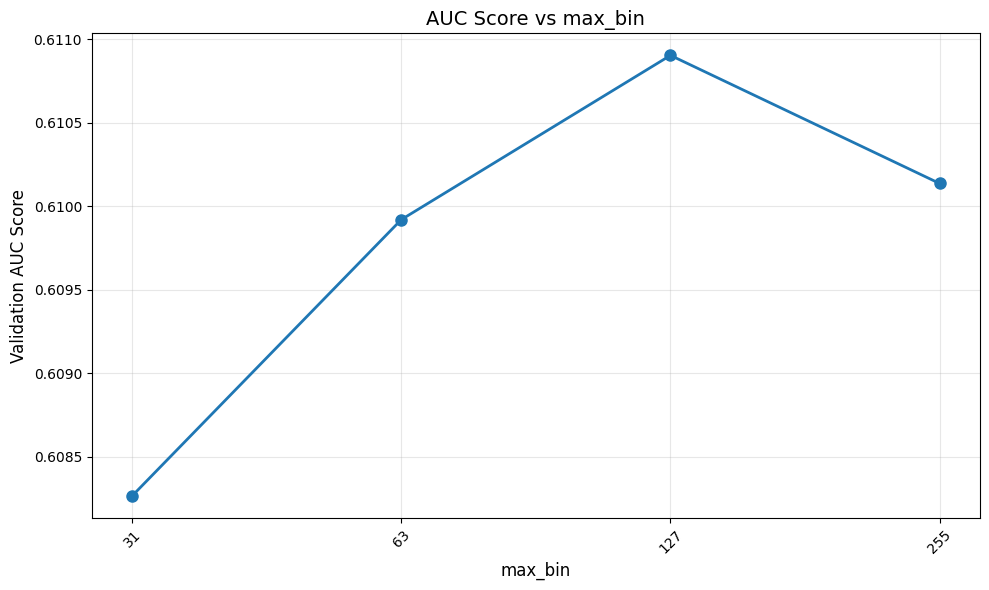

[0.6082643006727131,
 0.6099186037845064,
 0.6109021428071961,
 0.6101350343479262]

In [41]:
# max_bin
param_values = [31, 63, 127, 255]
auc_scores, xticks = tune('max_bin', param_values)
plot('max_bin', param_values, 'max_bin', auc_scores, xticks)

Started on boosting_type: goss
LightGBM from Scratch (vectorized) -> base_score = -3.277145 (initial prob = 0.036364, scale_pos_weight=1.0)
Tree 20/300 | Train AUC: 0.58860 (GOSS) | Val AUC: 0.59314
Tree 40/300 | Train AUC: 0.59782 (GOSS) | Val AUC: 0.60365
Tree 60/300 | Train AUC: 0.59918 (GOSS) | Val AUC: 0.60460
Tree 80/300 | Train AUC: 0.60343 (GOSS) | Val AUC: 0.60852
Tree 100/300 | Train AUC: 0.60344 (GOSS) | Val AUC: 0.60849
Tree 120/300 | Train AUC: 0.60251 (GOSS) | Val AUC: 0.60746
Tree 140/300 | Train AUC: 0.60391 (GOSS) | Val AUC: 0.60814
Tree 160/300 | Train AUC: 0.60415 (GOSS) | Val AUC: 0.60799
Tree 180/300 | Train AUC: 0.60403 (GOSS) | Val AUC: 0.60829
Tree 200/300 | Train AUC: 0.60523 (GOSS) | Val AUC: 0.60914
Tree 220/300 | Train AUC: 0.60533 (GOSS) | Val AUC: 0.60940
Tree 240/300 | Train AUC: 0.60536 (GOSS) | Val AUC: 0.60958
Tree 260/300 | Train AUC: 0.60536 (GOSS) | Val AUC: 0.60935
Tree 280/300 | Train AUC: 0.60595 (GOSS) | Val AUC: 0.60985
Tree 300/300 | Train AUC

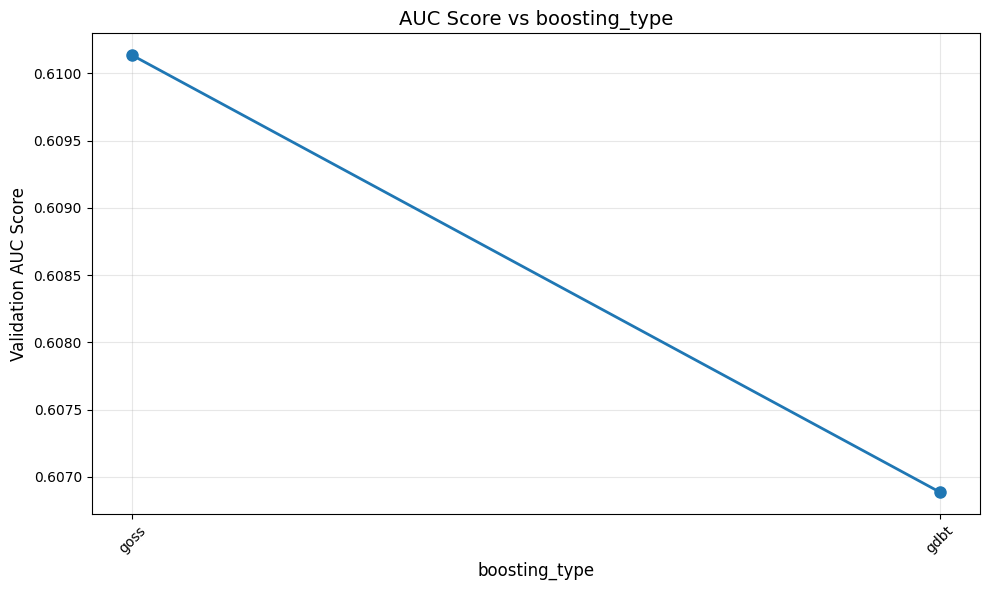

[0.6101350343479262, 0.6068875513507309]

In [42]:
# boosting_type
param_values = ['goss', 'gdbt']
auc_scores, xticks = tune('boosting_type', param_values)
plot('boosting_type', param_values, 'boosting_type', auc_scores, xticks)

Started on top_rate: 0.1
LightGBM from Scratch (vectorized) -> base_score = -3.277145 (initial prob = 0.036364, scale_pos_weight=1.0)
Tree 20/300 | Train AUC: 0.60189 (GOSS) | Val AUC: 0.60345
Tree 40/300 | Train AUC: 0.60443 (GOSS) | Val AUC: 0.60539
Tree 60/300 | Train AUC: 0.60742 (GOSS) | Val AUC: 0.60718
Tree 80/300 | Train AUC: 0.60794 (GOSS) | Val AUC: 0.60769
Tree 100/300 | Train AUC: 0.60928 (GOSS) | Val AUC: 0.60850
Tree 120/300 | Train AUC: 0.60880 (GOSS) | Val AUC: 0.60871
Tree 140/300 | Train AUC: 0.60882 (GOSS) | Val AUC: 0.60868
Tree 160/300 | Train AUC: 0.60881 (GOSS) | Val AUC: 0.60870
Tree 180/300 | Train AUC: 0.60873 (GOSS) | Val AUC: 0.60871
Tree 200/300 | Train AUC: 0.60948 (GOSS) | Val AUC: 0.60881
Tree 220/300 | Train AUC: 0.61015 (GOSS) | Val AUC: 0.61002
Tree 240/300 | Train AUC: 0.61007 (GOSS) | Val AUC: 0.61016
Tree 260/300 | Train AUC: 0.61001 (GOSS) | Val AUC: 0.61013
Tree 280/300 | Train AUC: 0.60981 (GOSS) | Val AUC: 0.60963
Tree 300/300 | Train AUC: 0.60

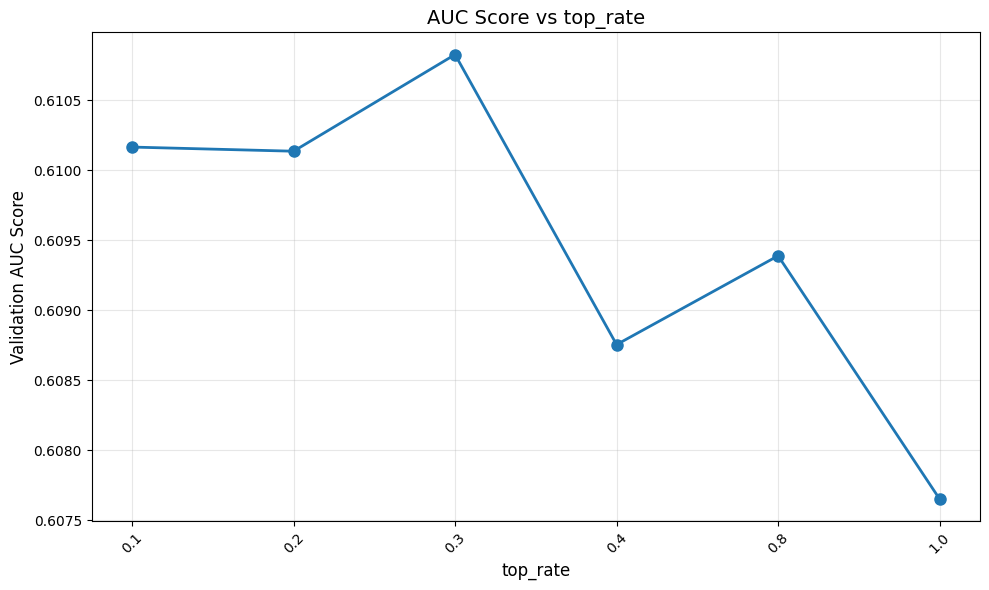

[0.6101646390172275,
 0.6101350343479262,
 0.6108251496352787,
 0.6087542639587169,
 0.6093883266705802,
 0.6076515541239554]

In [43]:
# top_rate
param_values = [0.1, 0.2, 0.3, 0.4, 0.8, 1.0]
auc_scores, xticks = tune('top_rate', param_values)
plot('top_rate', param_values, 'top_rate', auc_scores, xticks)

Started on other_rate: 0.1
LightGBM from Scratch (vectorized) -> base_score = -3.277145 (initial prob = 0.036364, scale_pos_weight=1.0)
Tree 20/300 | Train AUC: 0.58860 (GOSS) | Val AUC: 0.59314
Tree 40/300 | Train AUC: 0.59782 (GOSS) | Val AUC: 0.60365
Tree 60/300 | Train AUC: 0.59918 (GOSS) | Val AUC: 0.60460
Tree 80/300 | Train AUC: 0.60343 (GOSS) | Val AUC: 0.60852
Tree 100/300 | Train AUC: 0.60344 (GOSS) | Val AUC: 0.60849
Tree 120/300 | Train AUC: 0.60251 (GOSS) | Val AUC: 0.60746
Tree 140/300 | Train AUC: 0.60391 (GOSS) | Val AUC: 0.60814
Tree 160/300 | Train AUC: 0.60415 (GOSS) | Val AUC: 0.60799
Tree 180/300 | Train AUC: 0.60403 (GOSS) | Val AUC: 0.60829
Tree 200/300 | Train AUC: 0.60523 (GOSS) | Val AUC: 0.60914
Tree 220/300 | Train AUC: 0.60533 (GOSS) | Val AUC: 0.60940
Tree 240/300 | Train AUC: 0.60536 (GOSS) | Val AUC: 0.60958
Tree 260/300 | Train AUC: 0.60536 (GOSS) | Val AUC: 0.60935
Tree 280/300 | Train AUC: 0.60595 (GOSS) | Val AUC: 0.60985
Tree 300/300 | Train AUC: 0.

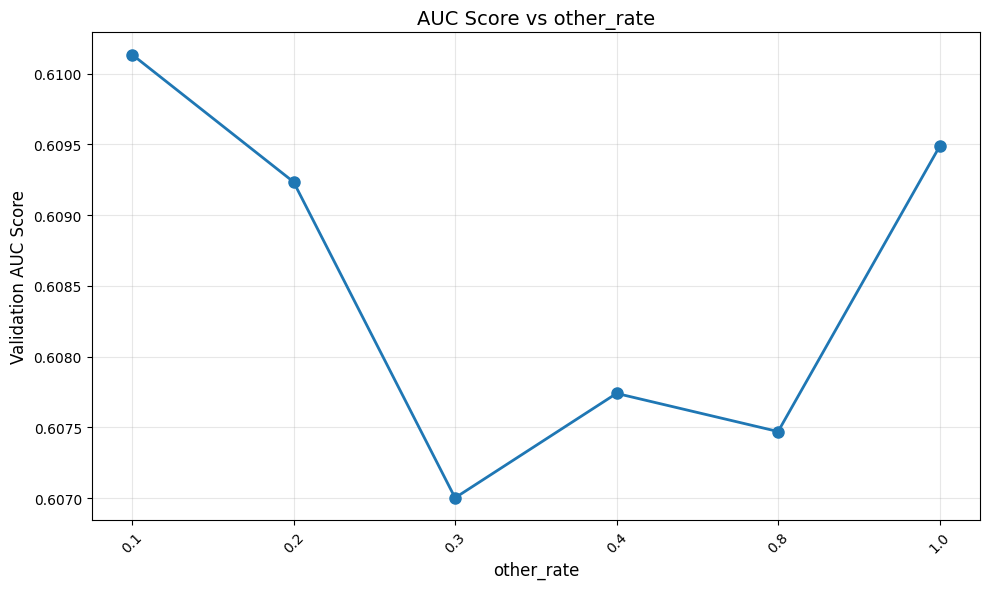

[0.6101350343479262,
 0.6092344124355475,
 0.6070013230162462,
 0.607739528865524,
 0.6074699671346108,
 0.6094855844189062]

In [44]:
# other_rate
param_values = [0.1, 0.2, 0.3, 0.4, 0.8, 1.0]
auc_scores, xticks = tune('other_rate', param_values)
plot('other_rate', param_values, 'other_rate', auc_scores, xticks)

Started on scale_pos_weight: 5
LightGBM from Scratch (vectorized) -> base_score = -1.667707 (initial prob = 0.158730, scale_pos_weight=5)
Tree 20/300 | Train AUC: 0.58025 (GOSS) | Val AUC: 0.57429
Tree 40/300 | Train AUC: 0.59872 (GOSS) | Val AUC: 0.60567
Tree 60/300 | Train AUC: 0.60080 (GOSS) | Val AUC: 0.60789
Tree 80/300 | Train AUC: 0.60291 (GOSS) | Val AUC: 0.60768
Tree 100/300 | Train AUC: 0.60372 (GOSS) | Val AUC: 0.60804
Tree 120/300 | Train AUC: 0.60782 (GOSS) | Val AUC: 0.60944
Tree 140/300 | Train AUC: 0.60844 (GOSS) | Val AUC: 0.60961
Tree 160/300 | Train AUC: 0.60876 (GOSS) | Val AUC: 0.60982
Tree 180/300 | Train AUC: 0.60906 (GOSS) | Val AUC: 0.61056
Tree 200/300 | Train AUC: 0.60916 (GOSS) | Val AUC: 0.61048
Tree 220/300 | Train AUC: 0.60947 (GOSS) | Val AUC: 0.61111
Tree 240/300 | Train AUC: 0.61073 (GOSS) | Val AUC: 0.61122
Tree 260/300 | Train AUC: 0.61051 (GOSS) | Val AUC: 0.61114
Tree 280/300 | Train AUC: 0.61065 (GOSS) | Val AUC: 0.61142
Tree 300/300 | Train AUC: 

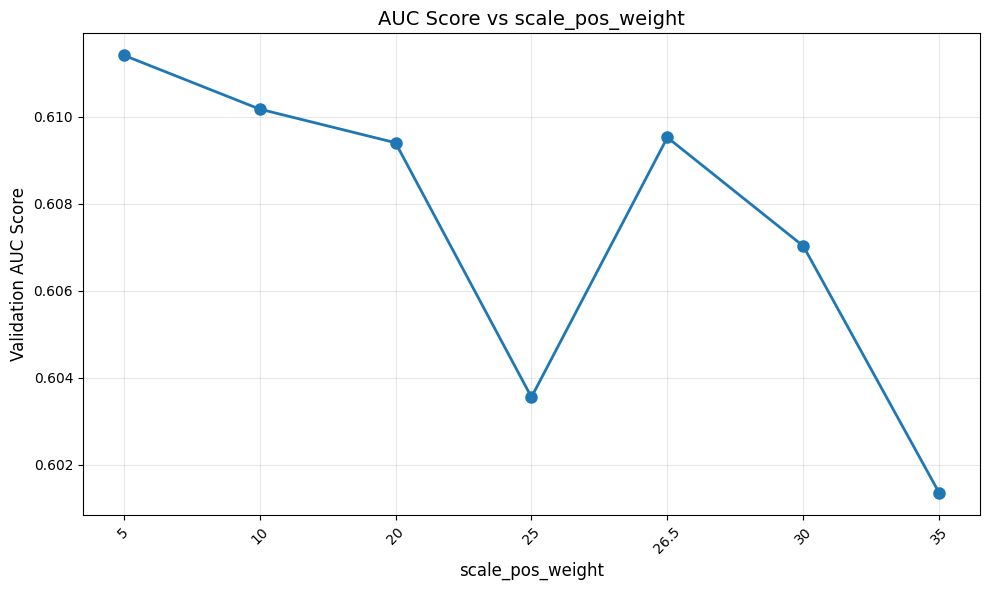

[0.6114209305853231,
 0.6101820542944427,
 0.609407633802339,
 0.603556495253428,
 0.6095293294239946,
 0.607031459487963,
 0.601353517268065]

In [45]:
# scale_pos_weight
param_values = [5, 10, 20, 25, 26.5, 30, 35]
auc_scores, xticks = tune('scale_pos_weight', param_values)
plot('scale_pos_weight', param_values, 'scale_pos_weight', auc_scores, xticks)

## Model training

### Model - test

In [6]:
model_lgb_test = LightGBM(
    num_iterations=50,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=4,
    min_data_in_leaf=20,
    min_sum_hessian_in_leaf=1e-3,

    feature_fraction=0.2,#np.float32(np.sqrt(X_train.shape[1])),
    bagging_fraction=0.85,

    reg_alpha=0.5,
    reg_lambda=8.0,

    min_split_gain=1e-3,
    max_bin=255,
    boosting_type='goss',
    top_rate=0.2,
    other_rate=0.1,
    scale_pos_weight=5.0,

    seed=42,
    early_stopping_rounds=20,
    verbose_eval=20
)

import time
start = time.time()
model_lgb_test.fit(X_train, y_train, X_valid, y_valid)
end = time.time()
print("LGBM Boost Model test Training time: ", (end - start)/60, "mins.")
print(f"LGBM Val AUC: {model_lgb_test.best_val_auc:.5f} at iteration: {model_lgb_test.best_iteration_}")

LightGBM from Scratch (vectorized) -> base_score = -1.666164 (initial prob = 0.158936, scale_pos_weight=5.0)
Tree 20/50 | Train AUC: 0.60743 (GOSS) | Val AUC: 0.60562
Tree 40/50 | Train AUC: 0.61331 (GOSS) | Val AUC: 0.61137
LGBM Boost Model test Training time:  0.5699439565340678 mins.
LGBM Val AUC: 0.61137 at iteration: 40


### CV + Grid Search

In [ ]:
# param_grid = {
#     'min_data_in_leaf': [20, 40],           # 40 was best
#     'feature_fraction': [0.3, 0.4, 0.5],    # 0.4 was best
#     'reg_lambda': [8.0, 12.0],              # 8–12 range was strong
#     'scale_pos_weight': [25.0, 27.0, 30.0], # bracketed the true ratio
# }

    # 'num_iterations': 800,          # high + early stopping
    # 'learning_rate': 0.04,

    # 'num_leaves': 31,               # stable choice
    # 'max_depth': 6,                 # leaf-wise growth
    # 'min_sum_hessian_in_leaf': 1e-3,
    # 'min_split_gain': 0.001,
    # 'reg_alpha': 0.5,

    # 'max_bin': 255,
    # 'boosting_type': 'goss',
    # 'top_rate': 0.2,
    # 'other_rate': 0.1,
    # 'bagging_fraction': 0.8,
    # 'early_stopping_rounds': 80,
    # 'verbose_eval': 25,
    # 'seed': 42,

In [ ]:
from sklearn.model_selection import StratifiedKFold
import time

# param_grid = {
#     'scale_pos_weight': [25.0, 27.0, 30.0],     # most important
#     'num_leaves': [47, 63, 80],                 # capacity
#     'feature_fraction': [0.55, 0.65, 0.75],     # signal per tree
#     'reg_lambda': [5.0, 8.0, 12.0],             # regularization
# }

param_grid = {
    'learning_rate': [0.08, 0.1], # 'learning_rate': [0.04, 0.06],
    # 'reg_lambda': [8.0, 12.0],              # 8–12 range was strong
}


# Fixed parameters (best observed)
fixed_params = {
    'num_iterations': 2000,          # high + early stopping
    # 'learning_rate': 0.03,

    'num_leaves': 60,               # stable choice
    'max_depth': 6,                 # leaf-wise growth
    'min_data_in_leaf': 20,         # 40 was best
    'min_sum_hessian_in_leaf': 1e-3,
    'min_split_gain': 0.001,

    'reg_alpha': 0.1,
    'reg_lambda': 3.0,

    'feature_fraction': 0.2,    # 0.4 was best
    'bagging_fraction': 0.8,

    'max_bin': 255,
    'boosting_type': 'goss',
    'top_rate': 0.2,
    'other_rate': 0.1,

    'scale_pos_weight': 8.0,  # bracketed the true ratio

    'early_stopping_rounds': 110,
    'verbose_eval': 25,
    'seed': 42
}

X_df = df_train.drop(columns=['target'])
y_np = np.array(df_train['target']).ravel().astype(np.int32)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

best_score = -np.inf
best_params = None
test_preds = None

from itertools import product
param_combinations = list(product(*param_grid.values()))

for i, values in enumerate(param_combinations):
    params = dict(zip(param_grid.keys(), values))
    print(f"\n--- Combination {i+1}/{len(list(param_grid.values())[0])**len(param_grid)} ---", 
          f" \nVariable params: {params}")
    
    
    current_params = {**params, **fixed_params}
    fold_scores = []
    test_preds_fold = []
    start = time.time()

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_df, y_np), 1):
        fold_start = time.time()

        X_tr = X_df.iloc[train_idx]
        y_tr = y_np[train_idx]
        X_va = X_df.iloc[val_idx]
        y_va = y_np[val_idx]

        model = LightGBM(**current_params)
        model.fit(X_tr, y_tr, X_va, y_va)

        fold_auc = model.best_val_auc
        fold_scores.append(fold_auc)
        test_preds_fold.append(model.test_pred)

        print(f" Fold: {fold} → Best Val AUC: {fold_auc:.5f} | {(time.time() - fold_start)/60} mins.")
    
    mean_auc = np.mean(fold_scores)
    std_auc = np.std(fold_scores)
    total_time = time.time() - start

    print(f" → mean auc: {mean_auc:.5f} ± {std_auc:.5f} | Time: {total_time/60} mins.")

    if mean_auc > best_score:
        best_score = mean_auc
        best_params = params
        # best_models = models_fold
        print(f"  ★ New best! ★")



--- Combination 1/2 ---  
Variable params: {'learning_rate': 0.04}
LightGBM from Scratch (vectorized + memory-optimized) -> base_score = -1.195288 (initial prob = 0.232314, scale_pos_weight=8.0)
Tree 25/2000 | Train AUC: 0.60635 (GOSS) | Val AUC: 0.60384
Tree 50/2000 | Train AUC: 0.60977 (GOSS) | Val AUC: 0.60836
Tree 75/2000 | Train AUC: 0.61447 (GOSS) | Val AUC: 0.61202
Tree 100/2000 | Train AUC: 0.61665 (GOSS) | Val AUC: 0.61374
Tree 125/2000 | Train AUC: 0.61792 (GOSS) | Val AUC: 0.61502
Tree 150/2000 | Train AUC: 0.61950 (GOSS) | Val AUC: 0.61609
Tree 175/2000 | Train AUC: 0.62059 (GOSS) | Val AUC: 0.61690
Tree 200/2000 | Train AUC: 0.62165 (GOSS) | Val AUC: 0.61761
Tree 225/2000 | Train AUC: 0.62208 (GOSS) | Val AUC: 0.61806
Tree 250/2000 | Train AUC: 0.62279 (GOSS) | Val AUC: 0.61836
Tree 275/2000 | Train AUC: 0.62346 (GOSS) | Val AUC: 0.61868
Tree 300/2000 | Train AUC: 0.62414 (GOSS) | Val AUC: 0.61918
Tree 325/2000 | Train AUC: 0.62475 (GOSS) | Val AUC: 0.61958
Tree 350/2000 

KeyboardInterrupt: 

    <!-- num_iterations= 10000,          # high + early stopping
    learning_rate= 0.04,

    num_leaves= 60,               # stable choice
    max_depth= 6,                 # leaf-wise growth
    min_data_in_leaf=20,
    min_sum_hessian_in_leaf= 1e-3,

    feature_fraction=0.2,#np.float32(np.sqrt(X_train.shape[1])),
    bagging_fraction= 0.8,

    reg_alpha= 0.1,
    reg_lambda=3.0,

    min_split_gain= 0.001,
    max_bin= 255,
    boosting_type= 'goss',
    top_rate= 0.2,
    other_rate= 0.1,
    scale_pos_weight=8.0,

    early_stopping_rounds= 3800,
    verbose_eval= 70,
    seed= 42 -->

In [ ]:
# param_grid = {
#     'scale_pos_weight': [24.0, 26.5, 29.0],      # most impactful
#     'feature_fraction': [0.55, 0.65, 0.75],
#     'num_leaves': [100, 127, 150],
#     'reg_lambda': [3.0, 5.0, 8.0],               # increase = more regularization
#     'reg_alpha': [0.0, 0.1, 0.3],                # increase = more regularization
#     'learning_rate': [0.02, 0.03, 0.04]
# }

### Model - 1

In [ ]:
model_lgb_1 = LightGBM(
    num_iterations=3000,
    learning_rate=0.03,

    num_leaves=127,
    max_depth=-1,
    min_data_in_leaf=20,
    min_sum_hessian_in_leaf= 1e-3,

    feature_fraction=0.6,#np.float32(np.sqrt(X_train.shape[1])),
    bagging_fraction= 0.8,
    bagging_freq=5,

    reg_alpha= 0.1,
    reg_lambda=5.0,

    scale_pos_weight=26.5,
    min_split_gain= 0.0,
    max_bin= 255,
    boosting_type= 'goss',
    top_rate= 0.2,
    other_rate= 0.1,

    early_stopping_rounds= 160,
    verbose_eval= 50,
    seed= 42
)

import time
start = time.time()
model_lgb_1.fit(X_train, y_train, X_valid, y_valid)
end = time.time()
print("Light GBM Model 1 Training time: ", (end - start)/60, "mins.")
print(f"Light GBM Boost Val AUC: {model_lgb_1.best_val_auc:.5f} at iteration: {model_lgb_1.best_iteration_} and max num of leaves: {model_lgb_1.current_num_leaves}")

LightGBM from Scratch (optimized) -> base_score = 0.001543 (initial prob = 0.500386, scale_pos_weight=26.5)
Tree 50/3000 | Train AUC: 0.60584 (GOSS) | Val AUC: 0.60344
Tree 100/3000 | Train AUC: 0.60869 (GOSS) | Val AUC: 0.60647
Tree 150/3000 | Train AUC: 0.61059 (GOSS) | Val AUC: 0.60781
Tree 200/3000 | Train AUC: 0.61309 (GOSS) | Val AUC: 0.60959
Tree 250/3000 | Train AUC: 0.61433 (GOSS) | Val AUC: 0.61039
Tree 300/3000 | Train AUC: 0.61528 (GOSS) | Val AUC: 0.61111
Tree 350/3000 | Train AUC: 0.61631 (GOSS) | Val AUC: 0.61178
Tree 400/3000 | Train AUC: 0.61668 (GOSS) | Val AUC: 0.61207
Tree 450/3000 | Train AUC: 0.61727 (GOSS) | Val AUC: 0.61249
Tree 500/3000 | Train AUC: 0.61733 (GOSS) | Val AUC: 0.61267
Tree 550/3000 | Train AUC: 0.61753 (GOSS) | Val AUC: 0.61270
Tree 600/3000 | Train AUC: 0.61762 (GOSS) | Val AUC: 0.61275
Tree 650/3000 | Train AUC: 0.61777 (GOSS) | Val AUC: 0.61288
Tree 700/3000 | Train AUC: 0.61799 (GOSS) | Val AUC: 0.61303
Tree 750/3000 | Train AUC: 0.61824 (GOS

KeyboardInterrupt: 

In [35]:
model_lgb_1_D = LightGBM(
    num_iterations=4500,
    learning_rate=0.025,

    num_leaves=150,
    max_depth=12,
    min_data_in_leaf=15,
    min_sum_hessian_in_leaf= 1e-3,

    feature_fraction=0.55,#np.float32(np.sqrt(X_train.shape[1])),
    bagging_fraction= 0.85,
    bagging_freq=5,

    reg_alpha= 0.05,
    reg_lambda=10.0,

    scale_pos_weight=26.5,
    min_split_gain= 0.0,
    max_bin= 255,
    boosting_type= 'goss',
    top_rate= 0.2,
    other_rate= 0.1,

    early_stopping_rounds= 260,
    verbose_eval= 50,
    seed= 42
)

import time
start = time.time()
model_lgb_1_D.fit(X_train, y_train, X_valid, y_valid)
end = time.time()
print("Light GBM Model 1 Training time: ", (end - start)/60, "mins.")
print(f"Light GBM Boost Val AUC: {model_lgb_1_D.best_val_auc:.5f} at iteration: {model_lgb_1_D.best_iteration_} and max num of leaves: {model_lgb_1_D.current_num_leaves}")
# Val AUC: 0.61473

LightGBM from Scratch (optimized) -> base_score = 0.001543 (initial prob = 0.500386, scale_pos_weight=26.5)
Tree 50/4500 | Train AUC: 0.60518 (GOSS) | Val AUC: 0.59926
Tree 100/4500 | Train AUC: 0.60588 (GOSS) | Val AUC: 0.60120
Tree 150/4500 | Train AUC: 0.60713 (GOSS) | Val AUC: 0.60245
Tree 200/4500 | Train AUC: 0.60821 (GOSS) | Val AUC: 0.60344
Tree 250/4500 | Train AUC: 0.60969 (GOSS) | Val AUC: 0.60467
Tree 300/4500 | Train AUC: 0.61031 (GOSS) | Val AUC: 0.60536
Tree 350/4500 | Train AUC: 0.61180 (GOSS) | Val AUC: 0.60650
Tree 400/4500 | Train AUC: 0.61213 (GOSS) | Val AUC: 0.60681
Tree 450/4500 | Train AUC: 0.61284 (GOSS) | Val AUC: 0.60749
Tree 500/4500 | Train AUC: 0.61338 (GOSS) | Val AUC: 0.60775
Tree 550/4500 | Train AUC: 0.61450 (GOSS) | Val AUC: 0.60866
Tree 600/4500 | Train AUC: 0.61509 (GOSS) | Val AUC: 0.60916
Tree 650/4500 | Train AUC: 0.61550 (GOSS) | Val AUC: 0.60960
Tree 700/4500 | Train AUC: 0.61613 (GOSS) | Val AUC: 0.61022
Tree 750/4500 | Train AUC: 0.61660 (GOS

KeyboardInterrupt: 

In [64]:
#     num_iterations=3000,
#     learning_rate=0.03,

#     num_leaves=180,
#     max_depth=22,
#     min_data_in_leaf=15,
#     min_sum_hessian_in_leaf= 1e-3,

#     feature_fraction=0.4,#np.float32(np.sqrt(X_train.shape[1])),
#     bagging_fraction= 0.8,
#     bagging_freq=5,

#     reg_alpha= 0.05,
#     reg_lambda=4.0,

#     scale_pos_weight=26.5,
#     min_split_gain= 0.0,
#     max_bin= 255,
#     boosting_type= 'goss',
#     top_rate= 0.2,
#     other_rate= 0.1,

#     early_stopping_rounds= 160,
#     verbose_eval= 50,
#     seed= 42
# Val AUC: 0.60826
# Val AUC: 0.61473

model_lgb_1_D = LightGBM(
    num_iterations=5000,
    learning_rate=0.028,

    num_leaves=145,
    max_depth=12,
    min_data_in_leaf=18,
    min_sum_hessian_in_leaf= 1e-3,

    feature_fraction=0.48,#np.float32(np.sqrt(X_train.shape[1])),
    bagging_fraction= 0.82,
    bagging_freq=5,

    reg_alpha= 0.08,
    reg_lambda=7.5,

    scale_pos_weight=26.5,
    min_split_gain= 0.0,
    max_bin= 255,
    boosting_type= 'goss',
    top_rate= 0.2,
    other_rate= 0.1,

    early_stopping_rounds= 250,
    verbose_eval= 50,
    seed= 42
)

import time
start = time.time()
model_lgb_1_D.fit(X_train, y_train, X_valid, y_valid)
end = time.time()
print("Light GBM Model 1 Training time: ", (end - start)/60, "mins.")
print(f"Light GBM Boost Val AUC: {model_lgb_1_D.best_val_auc:.5f} at iteration: {model_lgb_1_D.best_iteration_} and max num of leaves: {model_lgb_1_D.current_num_leaves}")

LightGBM from Scratch (optimized) -> base_score = 0.001543 (initial prob = 0.500386, scale_pos_weight=26.5)
Tree 50/5000 | Train AUC: 0.60777 (GOSS) | Val AUC: 0.60311
Tree 100/5000 | Train AUC: 0.60898 (GOSS) | Val AUC: 0.60482
Tree 150/5000 | Train AUC: 0.61129 (GOSS) | Val AUC: 0.60711
Tree 200/5000 | Train AUC: 0.61324 (GOSS) | Val AUC: 0.60835
Tree 250/5000 | Train AUC: 0.61400 (GOSS) | Val AUC: 0.60910
Tree 300/5000 | Train AUC: 0.61473 (GOSS) | Val AUC: 0.60961
Tree 350/5000 | Train AUC: 0.61661 (GOSS) | Val AUC: 0.61077
Tree 400/5000 | Train AUC: 0.61717 (GOSS) | Val AUC: 0.61146
Tree 450/5000 | Train AUC: 0.61825 (GOSS) | Val AUC: 0.61265
Tree 500/5000 | Train AUC: 0.61884 (GOSS) | Val AUC: 0.61321
Tree 550/5000 | Train AUC: 0.61991 (GOSS) | Val AUC: 0.61356
Tree 600/5000 | Train AUC: 0.62083 (GOSS) | Val AUC: 0.61417
Tree 650/5000 | Train AUC: 0.62128 (GOSS) | Val AUC: 0.61445
Tree 700/5000 | Train AUC: 0.62158 (GOSS) | Val AUC: 0.61452
Tree 750/5000 | Train AUC: 0.62196 (GOS

In [99]:
model_lgb_1_A = LightGBM(
    num_iterations=6000,
    learning_rate=0.018,

    num_leaves=155,
    max_depth=20,
    min_data_in_leaf=25,
    min_sum_hessian_in_leaf= 1e-3,

    feature_fraction=0.45,#np.float32(np.sqrt(X_train.shape[1])),
    bagging_fraction= 0.85,
    bagging_freq=5,

    reg_alpha= 0.15,
    reg_lambda=14.0, 

    scale_pos_weight= 26.5,# 26.46,
    min_split_gain= 0.0,
    max_bin= 255,
    boosting_type= 'goss',
    top_rate= 0.2,
    other_rate= 0.1,

    early_stopping_rounds= 300,
    verbose_eval= 50,
    seed= 42
)

import time
start = time.time()
model_lgb_1_A.fit(X_train, y_train, X_valid, y_valid)
end = time.time()
print("Light GBM Model 1 Training time: ", (end - start)/60, "mins.")
print(f"Light GBM Boost Val AUC: {model_lgb_1_A.best_val_auc:.5f} at iteration: {model_lgb_1_A.best_iteration_} and max num of leaves: {model_lgb_1_A.current_num_leaves}")



LightGBM from Scratch (optimized) -> base_score = 0.001543 (initial prob = 0.500386, scale_pos_weight=26.5)
Tree 50/6000 | Train AUC: 0.61289 (GOSS) | Val AUC: 0.60572
Tree 100/6000 | Train AUC: 0.61523 (GOSS) | Val AUC: 0.60792
Tree 150/6000 | Train AUC: 0.61740 (GOSS) | Val AUC: 0.60938
Tree 200/6000 | Train AUC: 0.61933 (GOSS) | Val AUC: 0.61085
Tree 250/6000 | Train AUC: 0.62117 (GOSS) | Val AUC: 0.61187
Tree 300/6000 | Train AUC: 0.62260 (GOSS) | Val AUC: 0.61262
Tree 350/6000 | Train AUC: 0.62437 (GOSS) | Val AUC: 0.61334
Tree 400/6000 | Train AUC: 0.62559 (GOSS) | Val AUC: 0.61422
Tree 450/6000 | Train AUC: 0.62617 (GOSS) | Val AUC: 0.61453
Tree 500/6000 | Train AUC: 0.62677 (GOSS) | Val AUC: 0.61467
Tree 550/6000 | Train AUC: 0.62789 (GOSS) | Val AUC: 0.61484
Tree 600/6000 | Train AUC: 0.62850 (GOSS) | Val AUC: 0.61522
Tree 650/6000 | Train AUC: 0.62876 (GOSS) | Val AUC: 0.61542
Tree 700/6000 | Train AUC: 0.62914 (GOSS) | Val AUC: 0.61567
Tree 750/6000 | Train AUC: 0.62973 (GOS

KeyboardInterrupt: 

In [105]:
model_lgb_1_B = LightGBM(
    num_iterations=6000,
    learning_rate=0.019,

    num_leaves=165,
    max_depth=20,
    min_data_in_leaf=28,
    min_sum_hessian_in_leaf= 1e-3,

    feature_fraction=0.46,#np.float32(np.sqrt(X_train.shape[1])),
    bagging_fraction= 0.83,
    bagging_freq=5,

    reg_alpha= 0.18,
    reg_lambda=15.0, 

    scale_pos_weight= 26.5,# 26.46,
    min_split_gain= 0.0,
    max_bin= 255,
    boosting_type= 'goss',
    top_rate= 0.2,
    other_rate= 0.1,

    early_stopping_rounds= 320,
    verbose_eval= 50,
    seed= 42
)

import time
start = time.time()
model_lgb_1_B.fit(X_train, y_train, X_valid, y_valid)
end = time.time()
print("Light GBM Model 1 Training time: ", (end - start)/60, "mins.")
print(f"Light GBM Boost Val AUC: {model_lgb_1_B.best_val_auc:.5f} at iteration: {model_lgb_1_B.best_iteration_} and max num of leaves: {model_lgb_1_B.current_num_leaves}")



LightGBM from Scratch (optimized) -> base_score = 0.001543 (initial prob = 0.500386, scale_pos_weight=26.5)
Tree 50/6000 | Train AUC: 0.61324 (GOSS) | Val AUC: 0.60417
Tree 100/6000 | Train AUC: 0.61405 (GOSS) | Val AUC: 0.60571
Tree 150/6000 | Train AUC: 0.61721 (GOSS) | Val AUC: 0.60815
Tree 200/6000 | Train AUC: 0.62049 (GOSS) | Val AUC: 0.61056
Tree 250/6000 | Train AUC: 0.62203 (GOSS) | Val AUC: 0.61167
Tree 300/6000 | Train AUC: 0.62368 (GOSS) | Val AUC: 0.61285
Tree 350/6000 | Train AUC: 0.62514 (GOSS) | Val AUC: 0.61370
Tree 400/6000 | Train AUC: 0.62626 (GOSS) | Val AUC: 0.61432
Tree 450/6000 | Train AUC: 0.62708 (GOSS) | Val AUC: 0.61474
Tree 500/6000 | Train AUC: 0.62783 (GOSS) | Val AUC: 0.61499
Tree 550/6000 | Train AUC: 0.62859 (GOSS) | Val AUC: 0.61521
Tree 600/6000 | Train AUC: 0.62959 (GOSS) | Val AUC: 0.61541
Tree 650/6000 | Train AUC: 0.62974 (GOSS) | Val AUC: 0.61551
Tree 700/6000 | Train AUC: 0.63004 (GOSS) | Val AUC: 0.61558
Tree 750/6000 | Train AUC: 0.63043 (GOS

### Submission Light GBM

In [108]:
y_preds_test = model_lgb_1_B.predict_proba(df_test)

submission = pd.DataFrame({
    "id": df_test['id'],
    "target": y_preds_test.round(4)
})

In [109]:
submission.to_csv("../Final-Submission/LightGBM-submission_best.csv")

### Sklearn Model

In [126]:
import pandas as pd
import numpy as np
import lightgbm as lgb   # ← THIS IS THE MISSING LINE
from sklearn.metrics import roc_auc_score
import time

# Your existing data (already loaded in previous cells)
# X_train, y_train, X_valid, y_valid, test = ...

# ==================== BEST PARAMETERS FROM TOP PORTO SUBMISSIONS ====================
params = {
    'boosting_type': 'goss',
    'objective': 'binary',
    'metric': 'auc',
    'n_estimators': 4000,
    'num_leaves': 120,
    'max_depth': 12,
    'learning_rate': 0.015,
    'feature_fraction': 0.52,        # most important
    'min_data_in_leaf': 40,
    'min_sum_hessian_in_leaf': 1e-3,

    'reg_alpha': 0.85,
    'reg_lambda': 22.0,              # strong regularization

    'scale_pos_weight': 26.5,        # your exact imbalance ratio
    'max_bin': 255,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1,
    # GOSS-specific (no bagging)
    'top_rate': 0.2,
    'other_rate': 0.1
}

model = lgb.LGBMClassifier(**params)

# ==================== TRAINING WITH EARLY STOPPING ====================
start = time.time()

eval_set = [(X_valid, y_valid)]

model.fit(
    X_train, y_train,
    eval_set=eval_set,
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=300, verbose=True),
        lgb.log_evaluation(50)
    ]
)

end = time.time()
print(f"Training time: {(end - start)/60:.2f} minutes")
print(f"Best iteration: {model.best_iteration_}")
print(f"Best Val AUC: {model.best_score_['valid_0']['auc']:.5f}")

# ==================== FINAL VALIDATION AUC ====================
val_pred = model.predict_proba(X_valid)[:, 1]
print(f"Final Val AUC: {roc_auc_score(y_valid, val_pred):.5f}")

Training until validation scores don't improve for 300 rounds
[50]	valid_0's auc: 0.628892
[100]	valid_0's auc: 0.631019
[150]	valid_0's auc: 0.632318
[200]	valid_0's auc: 0.633987
[250]	valid_0's auc: 0.634775
[300]	valid_0's auc: 0.635506
[350]	valid_0's auc: 0.635553
[400]	valid_0's auc: 0.636098
[450]	valid_0's auc: 0.635888
[500]	valid_0's auc: 0.635743
[550]	valid_0's auc: 0.635511
[600]	valid_0's auc: 0.635124
[650]	valid_0's auc: 0.634985
Early stopping, best iteration is:
[399]	valid_0's auc: 0.63614
Training time: 0.36 minutes
Best iteration: 399
Best Val AUC: 0.63614
Final Val AUC: 0.63614


In [131]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
import numpy as np
import time

# ==================== YOUR PARAM GRID (unchanged) ====================
param_grid = {
    'num_leaves': [110, 130, 150],
    'feature_fraction': [0.50, 0.52, 0.55],
    'reg_lambda': [20.0, 24.0, 28.0],
    'reg_alpha': [0.7, 0.9, 1.1],
    'min_data_in_leaf': [38, 42],
    'learning_rate': [0.013, 0.016]
}

# ==================== FIXED PARAMETERS ====================
fixed_params = {
    'boosting_type': 'goss',
    'objective': 'binary',
    'metric': 'auc',
    'n_estimators': 6000,
    'max_depth': 12,
    'min_sum_hessian_in_leaf': 1e-3,
    'scale_pos_weight': 26.5,
    'max_bin': 255,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1,
    'top_rate': 0.2,
    'other_rate': 0.1
}

X_df = df_train.drop(columns=['target'])
y_np = np.array(df_train['target']).ravel().astype(np.int32)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

best_score = -np.inf
best_params = None

print("Starting Grid Search with 3-fold CV...\n")

combination_count = 0
total_combinations = len(param_grid['num_leaves']) * \
                     len(param_grid['feature_fraction']) * \
                     len(param_grid['reg_lambda']) * \
                     len(param_grid['reg_alpha']) * \
                     len(param_grid['min_data_in_leaf']) * \
                     len(param_grid['learning_rate']) * 3   # 3 folds

for fold, (train_idx, val_idx) in enumerate(cv.split(X_df, y_np), 1):
    X_tr = X_df.iloc[train_idx]
    y_tr = y_np[train_idx]
    X_va = X_df.iloc[val_idx]
    y_va = y_np[val_idx]
    
    print(f"Fold {fold}/3 started...")
    
    for num_leaves in param_grid['num_leaves']:
        for feature_fraction in param_grid['feature_fraction']:
            for reg_lambda in param_grid['reg_lambda']:
                for reg_alpha in param_grid['reg_alpha']:
                    for min_data_in_leaf in param_grid['min_data_in_leaf']:
                        for learning_rate in param_grid['learning_rate']:
                            
                            combination_count += 1
                            if combination_count % 20 == 0:   # progress every 20 combos
                                print(f"  Progress: {combination_count}/{total_combinations} combinations completed")
                            
                            current_params = fixed_params.copy()
                            current_params.update({
                                'num_leaves': num_leaves,
                                'feature_fraction': feature_fraction,
                                'reg_lambda': reg_lambda,
                                'reg_alpha': reg_alpha,
                                'min_data_in_leaf': min_data_in_leaf,
                                'learning_rate': learning_rate
                            })
                            
                            model = lgb.LGBMClassifier(**current_params)
                            
                            model.fit(
                                X_tr, y_tr,
                                eval_set=[(X_va, y_va)],
                                eval_metric='auc',
                                callbacks=[
                                    lgb.early_stopping(300, verbose=False),
                                    lgb.log_evaluation(0)
                                ]
                            )
                            
                            val_auc = model.best_score_['valid_0']['auc']
                            
                            if val_auc > best_score:
                                best_score = val_auc
                                best_params = current_params.copy()
                                # Print ONLY variable params
                                var_params = {k: current_params[k] for k in param_grid.keys()}
                                print(f"  ★ New best: {val_auc:.5f} | {var_params}")

print("\n=== BEST PARAMETERS FOUND ===")
print(f"Best Val AUC: {best_score:.5f}")
for k, v in best_params.items():
    if k in param_grid:   # print only variable params
        print(f"  {k}: {v}")

Starting Grid Search with 3-fold CV...

Fold 1/3 started...
  ★ New best: 0.64003 | {'num_leaves': 110, 'feature_fraction': 0.5, 'reg_lambda': 20.0, 'reg_alpha': 0.7, 'min_data_in_leaf': 38, 'learning_rate': 0.013}
  ★ New best: 0.64152 | {'num_leaves': 110, 'feature_fraction': 0.5, 'reg_lambda': 20.0, 'reg_alpha': 0.7, 'min_data_in_leaf': 42, 'learning_rate': 0.013}
  Progress: 20/972 combinations completed
  Progress: 40/972 combinations completed
  Progress: 60/972 combinations completed
  Progress: 80/972 combinations completed
  Progress: 100/972 combinations completed
  Progress: 120/972 combinations completed
  Progress: 140/972 combinations completed
  Progress: 160/972 combinations completed
  Progress: 180/972 combinations completed
  Progress: 200/972 combinations completed
  Progress: 220/972 combinations completed
  Progress: 240/972 combinations completed
  Progress: 260/972 combinations completed
  Progress: 280/972 combinations completed
  Progress: 300/972 combinations

KeyboardInterrupt: 